# Predicting Student Success Using ML

Justyen Nguyen
ITAI-1371

## 1. Introduction

Machine learning is becoming more common in education, especially for predicting student performance and identifying students who may be at risk of failing. Predicting whether a student passes or fails could help schools provide help earlier instead of waiting until it's too late for an individual student. Companies like Coursera and Khan Academy already use ML to personalize learning experience and track student progress.

There are previous students that use the UCI Student Performance dataset using both regression and classification models to predict student grades. In these studies, preprocessing and feature engineering was found to improve the performance of the models. In a GritNet study, they used deep learning and student activity data to predict course completion and student success. Unlike previous studies that focus on predicting exact grades or uses more complex and deep learning systems, my project focuses on a simpler classification approach to predict whether a student passes or fails.

## 2. Problem Definition

The goal of this project is to predict whether a student will pass or fail using machine learning. The exact final grade won't be used and instead, we'll turn this problem into a binary classification problem where students are groups into either passing or failing based on their final grade (G3).

Input features include academic, demographic, and lifestyle-related factors. This includes thing such as study time, absences, parental education/occupation, internet access, and other features found in the UCI Student Performance dataset. The models for this project will be Logistic Regression, Decision Tree, and Random Forest to compare how well different they perform.

## 3. Approach, Materials, and Methods

This project uses the UCI Student Performance dataset, which contains 395 rows and 34 columns. Of those 34 features, approximately half of them are categorical, which needs to be encoded, and the dataset as a whole is clean with no missing values. Since this is a classification task, the final grade (G3) will need to be converted into a binary pass/fail target. Also, the dataset contains two previous grading periods (G1 and G2), so I will need to exclude those from the final model since in my preliminary testing, I found that they could influence the final grade prediction. Afterwards, we'll need to split the dataset into a 80-20 training/testing set for evaluation.

The three classification models that will be used in this project are:
- Logistic Regression (simple baseline)
- Decision Tree (captures nonlinear relationship between features)
- Random Forest (combines multiple decision trees to improve performance)

The models will be evaluated on on will be accuracy, precision, recall, F1-score, and confusion matrices.

### Preprocessing

In [25]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#Data Loading
df = pd.read_csv("student-mat.csv", sep=';')

# Convert final grade into binary classification target
df['Pass'] = (df['G3'] >= 10).astype(int)

#print(df.head())
#print(df.shape)
#print(df.columns)

#print(df[['G3', 'Pass']].head(10))
#print(df['Pass'].value_counts())

# Target variable
y = df['Pass']

# Features (exclude G1, G2, G3)
X = df.drop(['G1', 'G2', 'G3', 'Pass'], axis=1)

#print("Feature shape:", X.shape)
#print("Target shape:", y.shape)
#print(X.head())

# Convert categorical variables to numeric
X_encoded = X.copy()

categorical_cols = X_encoded.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X_encoded[col] = X_encoded[col].astype('category').cat.codes

#print("Encoded features:")
#print(X_encoded.head())
#print("\nPost encoding:")
#print(X_encoded.dtypes)

# 80-20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

#print("Train shape:", X_train.shape)
#print("Test shape:", X_test.shape)
#print("Train target shape:", y_train.shape)
#print("Test target shape:", y_test.shape)

## 4. Results

### Model 1: Logistic Regression

This will be our baseline model due to its simplicity so we'll be using it for our first model before testing more complex ones.

In [26]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-score:", f1_log)

Logistic Regression Results:
Accuracy: 0.759493670886076
Precision: 0.7619047619047619
Recall: 0.9230769230769231
F1-score: 0.8347826086956521


### Model 2: Decision Tree

In [27]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Results:")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)

Decision Tree Results:
Accuracy: 0.7088607594936709
Precision: 0.7543859649122807
Recall: 0.8269230769230769
F1-score: 0.7889908256880734


### Model 3: Random Forest

In [28]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Random Forest Results:
Accuracy: 0.7215189873417721
Precision: 0.7205882352941176
Recall: 0.9423076923076923
F1-score: 0.8166666666666667


### Confusion Matrix

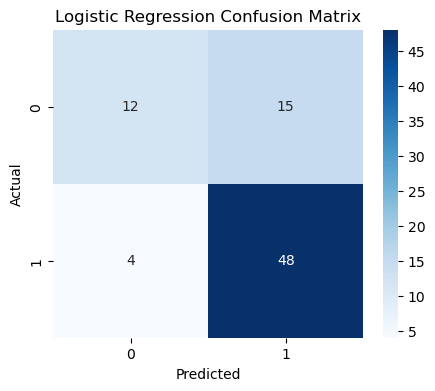

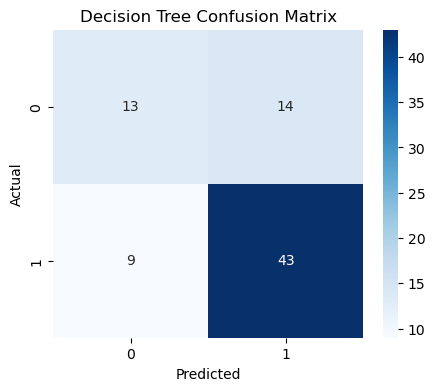

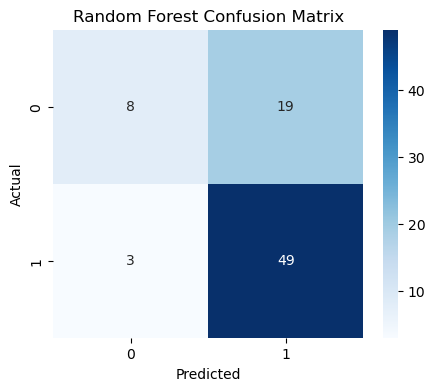

In [29]:
#Logistic Regression CM
cm_lr = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Decision Tree CM
cm_dt = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Random Forest CM
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Bar Graphs

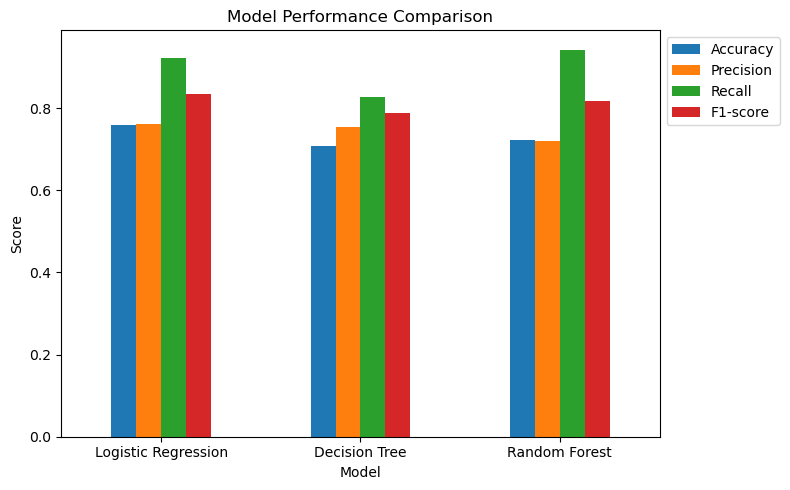

In [30]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracy = [accuracy_log, accuracy_tree, accuracy_rf]
precision = [precision_log, precision_tree, precision_rf]
recall = [recall_log, recall_tree, recall_rf]
f1 = [f1_log, f1_tree, f1_rf]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

#print(comparison_df)

ax = comparison_df.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()

plt.show()

## 5. Discussion

One of the first things I noticed was that this particular dataset contained 395 students where 265 passed and 130 failed. To me, the fact that there is already an imbalanced distribution of passes and fails already raised concern for me. I believe this affects accuracy and led me to believe that accuracy, alone, isn't enough to evaluate model performance. This is why i included additional metrics like precision, recall and F1 scores.

Across all the models, Logistic Regression performed most consistently overall. It had an accuracy of 75.95%, precision of 0.762, recall of 0.923, and an F1-score of 0.835. This implies that it was really good at identifying students that passed (high recall), and maintained relatively balanced overall predictions, reflected in the F1 score. This confusion matrix also supports this because it only had 4 false negatives, showing that not many passing students were incorrectly classified as failing.

Decision Tree had the worst performance across all models, with an accuracy of 70.89%, precision of 0.754, recall of 0.827, and an F1-score of 0.789. The drop in scores, compared to Logistic Regression shows that the model is less consistent at identifying true positive cases. The confusion matrix shows that this model has higher number of false positives (9) which indicates that more passing students were classified as failing. This reduces this model's reliability, despite having similar precision.

The most surprising result is the Random Forest model, with an accuracy of 72.15%, precision of 0.721 (lowest), recall of 0.942, and an F1-score of 0.817. It has very high recall, which indicates that it's really good at identifying passing students, which is supported by having only 3 false negatives. However, this also followed with the fact that it had increased false positives (19), which greatly lowered its precision. I believe this is due to the model being biased towards "pass", which I mentioned at the beginning of the discussion.

Another factor that likely affect the results is that I removed G1 and G2 before training. They were removed because they were early grade indicators that I didn't want to influence the target (G3). Without then the models had to rely on other features more, which may have taken some advantage away from the more complex models.

Overall, Logistic Regression had the best balance between all evaluation metrics. Random Forest was really good with recall, but it wasn't consistent and Decision Tree underperformed across most metrics. As a whole, I think this means that the relationship between all the features and outcomes in this dataset isn't that complex, which is why the simpler model ended up performing better than the complex ones.







## 6. Conclusion

In this project, I compared three machine learning models (Logistic Regession, Decision Tree, and Random Forest) to predict whether students would pass or fail, using the UCI Student Performance dataset. Logistic Regression performed the best overall, having the most balanced metrics, while Random Forest seemed to prioritize recall and Decision Tree performed the weakest.

I learned that preprocessing decisions, especially removing G1 and G2, significantly affected my model's performance and that accuracy alone isn't enough to evaluate classification models. Using confusion matrices and different metrics such as precision, recall, and F1-score are necessary for depth in understanding the model's performance.

For future improvements, I could include more advanced things like feature engineering, hyperparameter turning, and cross-validation to improve a model's reliability.